# EDA — Members: Demografía vs Churn
Análisis de `members_v3.csv` cruzado con etiquetas de `train.csv`.  
Cubre: ciudad, método de registro, género, edad y antigüedad vs churn rate.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))

from src.eda.members_03 import (
    load_members_labeled,
    analyze_demographics,
    plot_churn_by_city,
    plot_churn_by_registration,
    plot_churn_by_demographics,
    plot_tenure_distribution,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Carga de datos

In [2]:
df = load_members_labeled()

Usuarios en análisis: 877,161 | churn rate: 6.57%


In [3]:
df.head()

,msno,city,bd,gender,registered_via,registration_init_time,bd_valid,age,age_group,tenure_days,tenure_years,tenure_bucket,is_churn
0,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,unknown,7,2011-09-14,False,NaN,NaN,1994,5.5,5y+,0
1,yLkV2gbZ4GLFwqTOXLVHz0VGrMYcgBGgKZ3kj9RiYu8=,4,30,male,9,2011-09-16,True,30.0,25-35,1992,5.5,5y+,0
2,WH5Jq4mgtfUFXh2yz+HrcTXKS4Oess4k4W3qKolAeb0=,5,34,male,9,2011-09-16,True,34.0,25-35,1992,5.5,5y+,1
3,I0yFvqMoNkM8ZNHb617e1RBzIS/YRKemHO7Wj13EtA0=,13,63,male,9,2011-09-18,True,63.0,55+,1990,5.5,5y+,0
4,OoDwiKZM+ZGr9P3fRivavgOtglTEaNfWJO4KaJcTTts=,1,0,unknown,7,2011-09-18,False,NaN,NaN,1990,5.5,5y+,0


In [4]:
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["is_churn"].mean():.2%}')
print(f'\nNulos:')
print(df.isnull().sum())

Shape: (877161, 13)
Churn rate: 6.57%

Nulos:
msno                           0
city                           0
bd                             0
gender                         0
registered_via                 0
registration_init_time         0
bd_valid                       0
age                       488027
age_group                 488027
tenure_days                    0
tenure_years                   0
tenure_bucket                 21
is_churn                       0
dtype: int64


## 2. Análisis demográfico

In [5]:
results = analyze_demographics(df)

═══════════════════════════════════════════════════════
CHURN RATE GLOBAL: 6.57%

── Por método de registro ──
                churn_rate       n
registered_via                    
4                 0.182558   49283
3                 0.127090  105445
9                 0.086362  236620
13                0.085196    3087
7                 0.030160  482726

── Por género ──
         churn_rate       n
gender                     
male       0.088446  206284
female     0.086366  185408
unknown    0.048195  485469

── Por grupo de edad ──
           churn_rate       n
age_group                    
<18          0.192960   17216
18-25        0.114979  117439
25-35        0.071033  169568
35-45        0.068280   59095
45-55        0.057674   20373
55+          0.061363    5443

── Por antigüedad ──
               churn_rate       n
tenure_bucket                    
<3m              0.094640   33506
3-12m            0.059607  141963
1-2y             0.068107  197057
2-3y             0.083813   8

## 3. Churn rate por ciudad

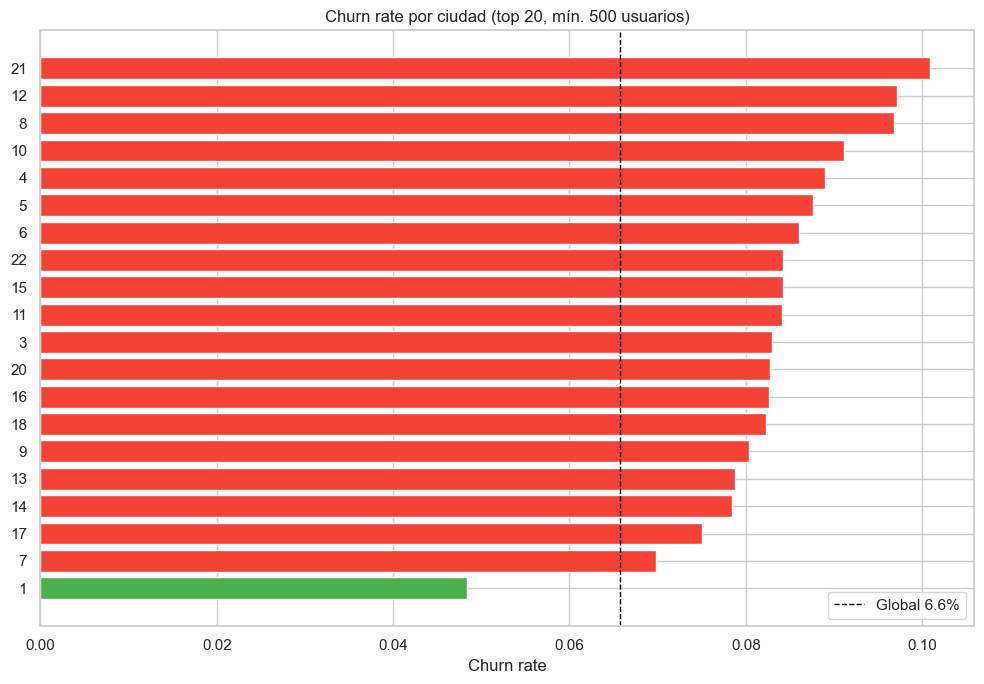

In [6]:
plot_churn_by_city(results)

## 4. Churn rate por método de registro

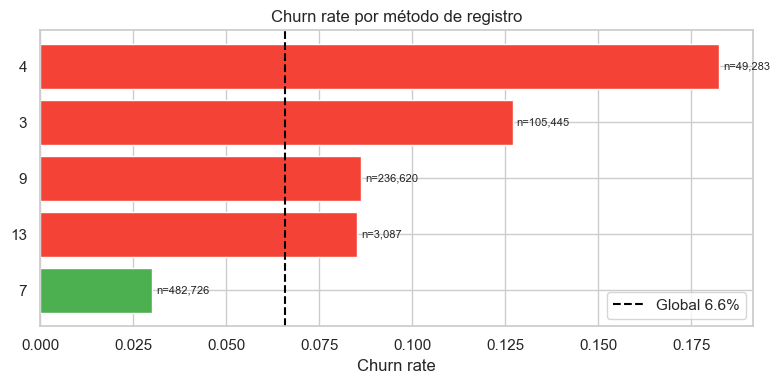

In [7]:
plot_churn_by_registration(results)

In [8]:
# Desglose completo
reg = results['reg_churn'].copy()
reg['lift'] = reg['churn_rate'] / results['global_rate']
reg.sort_values('churn_rate', ascending=False)

,churn_rate,n,lift
registered_via,,,
4,0.182558,49283,2.777429
3,0.127090,105445,1.933542
9,0.086362,236620,1.313910
13,0.085196,3087,1.296168
7,0.030160,482726,0.458853


## 5. Churn rate por perfil demográfico (género, edad, antigüedad)

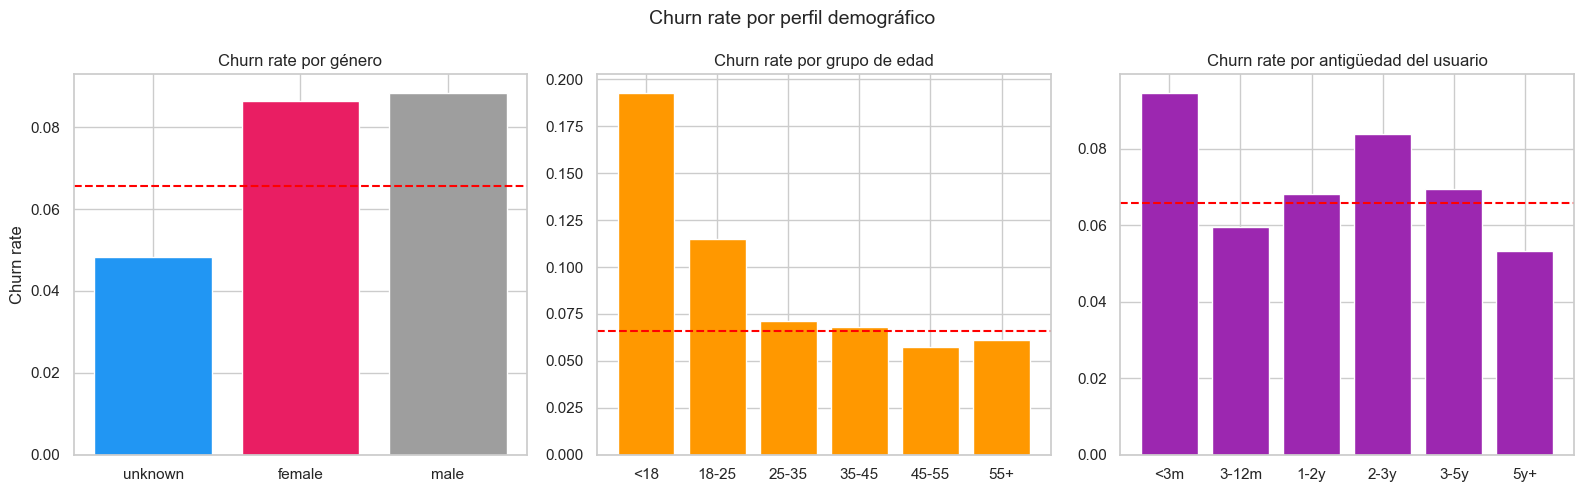

In [9]:
plot_churn_by_demographics(results)

In [10]:
# Tabla resumen: edad
age = results['age_churn'].copy()
age['lift'] = age['churn_rate'] / results['global_rate']
age

,churn_rate,n,lift
age_group,,,
<18,0.192960,17216,2.935687
18-25,0.114979,117439,1.749284
25-35,0.071033,169568,1.080700
35-45,0.068280,59095,1.038808
45-55,0.057674,20373,0.877456
55+,0.061363,5443,0.933578


In [11]:
# Tabla resumen: antigüedad
ten = results['tenure_churn'].copy()
ten['lift'] = ten['churn_rate'] / results['global_rate']
ten

,churn_rate,n,lift
tenure_bucket,,,
<3m,0.094640,33506,1.439846
3-12m,0.059607,141963,0.906860
1-2y,0.068107,197057,1.036180
2-3y,0.083813,85046,1.275135
3-5y,0.069426,194813,1.056238
5y+,0.053156,224755,0.808708


## 6. Distribución de antigüedad + top ciudades

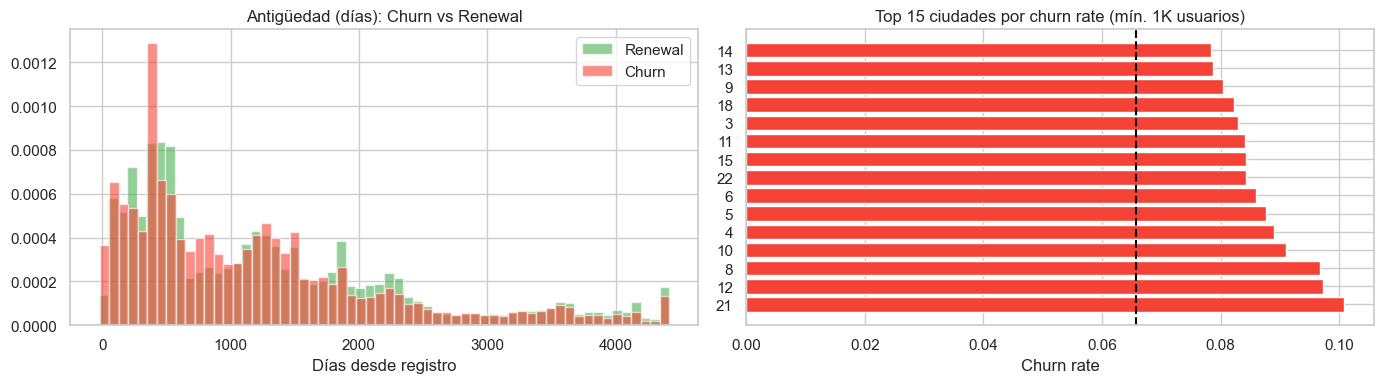

In [12]:
plot_tenure_distribution(df)

## 7. Distribución de edad (válida vs total)

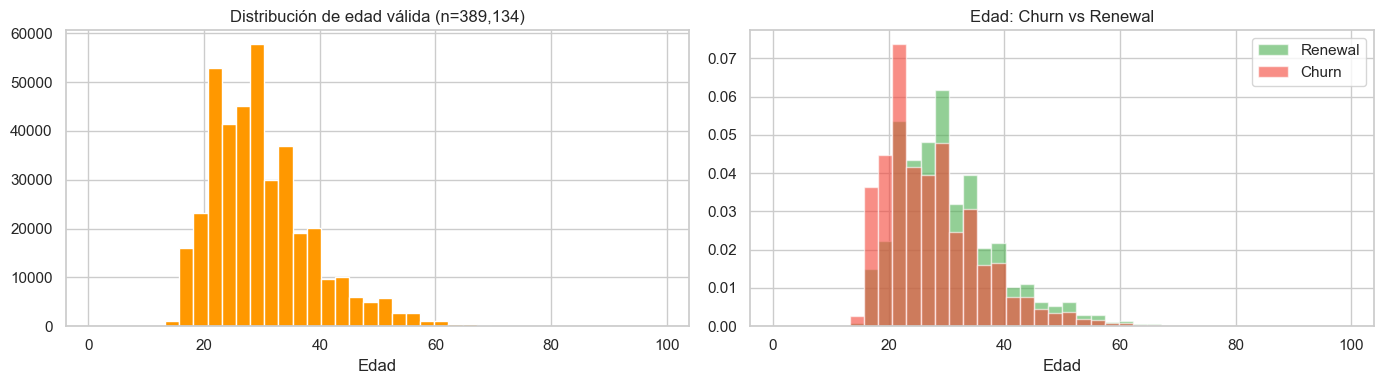

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid_age = df.dropna(subset=['age'])
axes[0].hist(valid_age['age'], bins=40, color='#FF9800', edgecolor='white')
axes[0].set_title(f'Distribución de edad válida (n={len(valid_age):,})')
axes[0].set_xlabel('Edad')

for label, color in [(0, '#4CAF50'), (1, '#F44336')]:
    subset = valid_age[valid_age['is_churn'] == label]['age']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color,
                 label='Renewal' if label == 0 else 'Churn', density=True)
axes[1].set_title('Edad: Churn vs Renewal')
axes[1].set_xlabel('Edad')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Resumen de hallazgos

| Variable | Hallazgo clave |
|---|---|
| `registered_via` | Métodos 4 y 3 tienen churn 2–3× el promedio; método 7 (55% de usuarios) muy bajo |
| `gender` | `unknown` (55%) tiene churn más bajo — usuarios más pasivos/corporativos |
| `bd` (edad) | Churn cae con la edad: menores de 18 al 19.3%, mayores 55+ al 6.1% |
| `tenure` | Mayor churn en nuevos (<3m) y pico en 2–3 años; más fieles en 5y+ |
| `city` | Variación notable entre ciudades (filtrado a ≥500 usuarios) |